In [5]:
# for src folder access
import sys
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import os
import pandas as pd
from matplotlib import pyplot as plt

from src.config import TRIMMED_DATA_ROOT, ACTIVE_SECTIONS_DATA_ROOT, default_session_to_activity
from src.preprocessing.clap_sync import accel_magnitude, simple_clap_sync

TRIMMED_DATA_ROOT

WindowsPath('C:/Users/TUFA17/OneDrive/Desktop/HAR_Projekt_LSTM_added_class/ax6_cnn_project/data/trimmed')

In [6]:
filenames = os.listdir(TRIMMED_DATA_ROOT)
filenames

['12left.csv',
 '12right.csv',
 '13left.csv',
 '13right.csv',
 '14left.csv',
 '14right.csv',
 '15left.csv',
 '15right.csv',
 '16left.csv',
 '16right.csv',
 '17left.csv',
 '17right.csv',
 '18left.csv',
 '18right.csv',
 '19left.csv',
 '19right.csv',
 '20left.csv',
 '20right.csv',
 '21left.csv',
 '21right.csv',
 '22left.csv',
 '22right.csv',
 '23left.csv',
 '23right.csv',
 '24left.csv',
 '24right.csv',
 '25left.csv',
 '25right.csv',
 '26left.csv',
 '26right.csv',
 '27left.csv',
 '27right.csv']

### Example data

In [10]:
dfs = []
dfs_ = []
for filename in filenames:
    dfs_.append(pd.read_csv(os.path.join(TRIMMED_DATA_ROOT, filename)))
    if len(dfs_) == 2:
        dfs.append(dfs_)
        dfs_ = []

dfs[0][0]

,t,ax,ay,az,gx,gy,gz,acc_mag
0,1.00,0.505371,0.345703,-0.408447,-249.992355,15.411376,-249.992355,0.736029
1,1.01,0.130615,0.476563,-0.349854,-249.992355,-17.845154,-249.992355,0.605451
2,1.02,0.731934,0.337646,-0.662109,-249.992355,-92.864983,-249.992355,1.043130
3,1.03,0.880859,0.305908,-0.817871,-249.992355,-59.089657,-243.148788,1.240325
4,1.04,0.790771,0.063965,-0.759277,-249.992355,-10.002136,-221.031174,1.098140
...,...,...,...,...,...,...,...,...
4539,46.39,-0.084473,-0.582764,1.070801,-83.740227,-29.624937,-27.603148,1.222033
4540,46.40,-0.034668,-0.614014,1.047363,-79.360962,-27.282713,-25.245665,1.214572
4541,46.41,-0.010742,-0.635986,1.021484,-73.547363,-18.920898,-21.522520,1.203338
4542,46.42,0.414551,-1.385742,0.583740,-68.687439,-61.950680,-7.141113,1.559771


### Synchronisation

In [12]:
for dfL, dfR in dfs:
    dfL["acc_mag"] = accel_magnitude(dfL)
    dfR["acc_mag"] = accel_magnitude(dfR)
dfs_synced = [simple_clap_sync(dfL, dfR, search_samples=10) for dfL, dfR in dfs]

In [15]:
print(type(dfs_synced[0]), len(dfs_synced[0]))


<class 'tuple'> 3


### First seconds

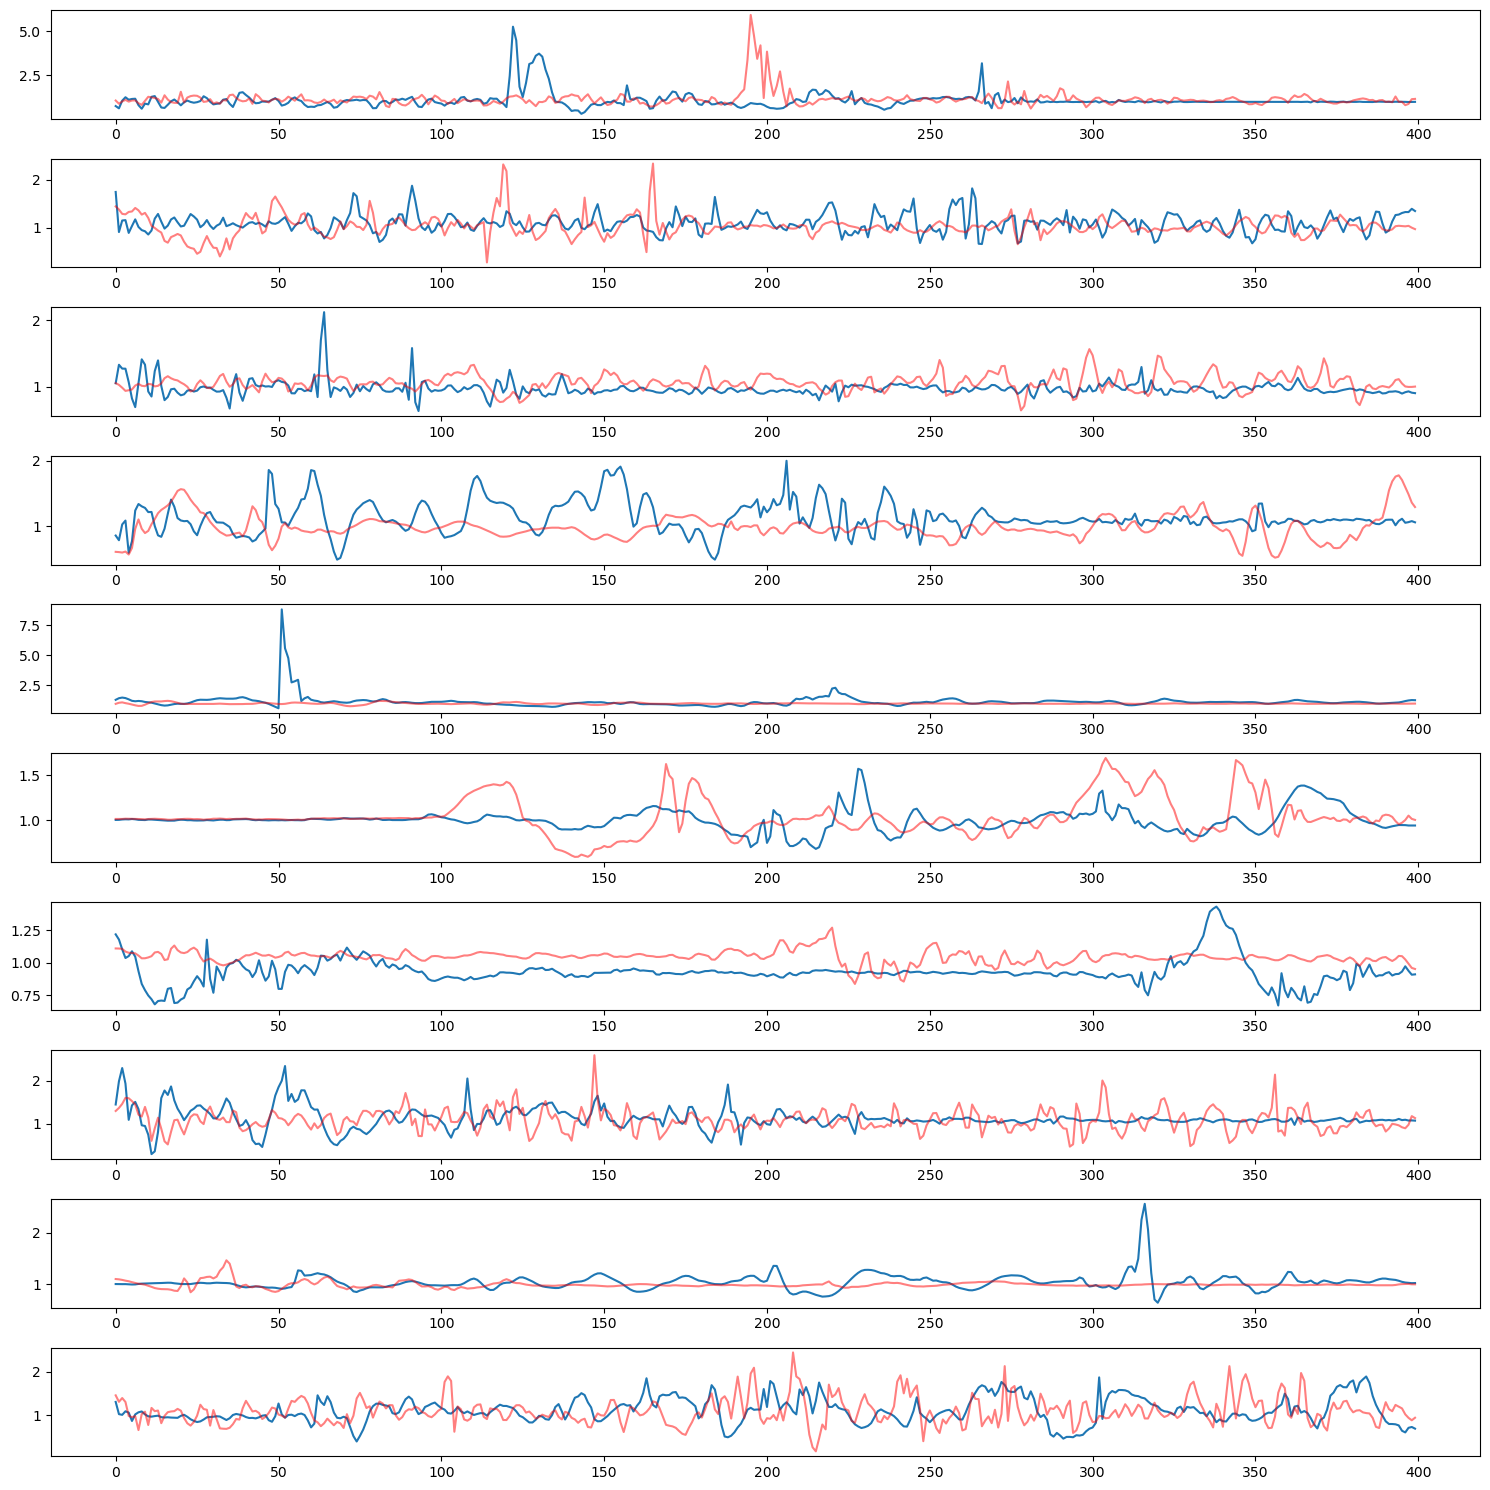

In [16]:
fig, ax = plt.subplots(10, 1, figsize=(15, 15))
for axis, out in zip(ax, dfs_synced):
    dfL, dfR = out[0], out[1]
    dfL["acc_mag"][:400].plot(ax=axis)
    dfR["acc_mag"][:400].plot(ax=axis, color="r", alpha=0.5)


plt.tight_layout()

In [26]:
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd

class FourLineCutter:
    def __init__(self, dfL, dfR, exercise_id):
        self.dfL = dfL
        self.dfR = dfR
        self.feature_cols = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']
        
        self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(15, 4), sharex=True)
        
        # Hintergründe plotten
        self.ax1.plot(dfL.index, dfL["acc_mag"], color="royalblue", lw=1, label="Links")
        self.ax2.plot(dfR.index, dfR["acc_mag"], color="darkorange", lw=1, label="Rechts")
        
        self.ax1.set_title(f"High-Speed Cutting: {exercise_id}")
        self.ax1.legend()

        # Initiale Positionen
        idx = dfL.index
        pos = [idx[int(len(idx)*p)] for p in [0.1, 0.2, 0.7, 0.8]]
        
        self.lines = []
        self.active_line = None
        
        # 4 Linien-Paare erstellen (immer 2 pro Zeitpunkt: eine oben, eine unten)
        # Wir speichern sie als Paare, um sie später synchronisieren zu können
        colors = ['red', 'red', 'green', 'green']
        self.line_pairs = []
        
        for p, col in zip(pos, colors):
            l1 = self.ax1.axvline(p, color=col, lw=2, picker=10)
            l2 = self.ax2.axvline(p, color=col, lw=2, picker=10)
            self.line_pairs.append([l1, l2])
            self.lines.extend([l1, l2])

        # Event-Binding
        self.fig.canvas.mpl_connect('pick_event', self.on_pick)
        self.fig.canvas.mpl_connect('motion_notify_event', self.on_motion)
        self.fig.canvas.mpl_connect('button_release_event', self.on_release)

        plt.tight_layout()
        
        # Blitting-Vorbereitung: Hintergrund speichern
        self.bg = None
        self.fig.canvas.draw()

    def on_pick(self, event):
        if event.artist in self.lines:
            self.active_line = event.artist
            # Den Hintergrund ohne die Linien "einfrieren" für flüssiges Ziehen
            # (In Jupyter/Widget manchmal schwierig, daher nutzen wir hier die simple Variante,
            # reduzieren aber die Redraw-Last)

    def on_motion(self, event):
        if self.active_line and event.xdata is not None:
            # Nur die aktuell gezogene Linie updaten
            self.active_line.set_xdata([event.xdata, event.xdata])
            # draw_idle ist effizienter als draw()
            self.fig.canvas.draw_idle() 

    def on_release(self, event):
        if self.active_line:
            curr_x = self.active_line.get_xdata()
            # Partner finden und nachziehen (nach dem Loslassen)
            for pair in self.line_pairs:
                if self.active_line in pair:
                    pair[0].set_xdata(curr_x)
                    pair[1].set_xdata(curr_x)
            
            self.active_line = None
            self.fig.canvas.draw_idle()

    def get_data(self):
        # Extract all 4 line x-positions (from top plot lines)
        xs = sorted([pair[0].get_xdata()[0] for pair in self.line_pairs])
        x1, x2, x3, x4 = xs  # red1, red2, green1, green2 in time order

        # ✅ CUT BETWEEN CLAPS:
        # activity starts after the start clap (x2) and ends before the end clap (x3)
        start = x2
        end = x3

        # (optional) add small margins so you don't include clap residuals
        # start += 0.25 * 100   # 0.25 sec if fs=100
        # end   -= 0.25 * 100

        start = int(max(0, start))
        end = int(min(len(self.dfL) - 1, end))

        cL = self.dfL.loc[start:end, self.feature_cols].copy()
        cR = self.dfR.loc[start:end, self.feature_cols].copy()

        return cL, cR



### Manual extraction

In [27]:
dfs_synced_pairs = []
offsets = []

for out in dfs_synced:
    dfL, dfR = out[0], out[1]   # take only the first two
    dfs_synced_pairs.append((dfL, dfR))

# overwrite so the rest of the notebook works unchanged
dfs_synced = dfs_synced_pairs

C:\Users\TUFA17\AppData\Local\Temp\ipykernel_11020\3041334067.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  self.fig, (self.ax1, self.ax2) = plt.subplots(2, 1, figsize=(15, 4), sharex=True)


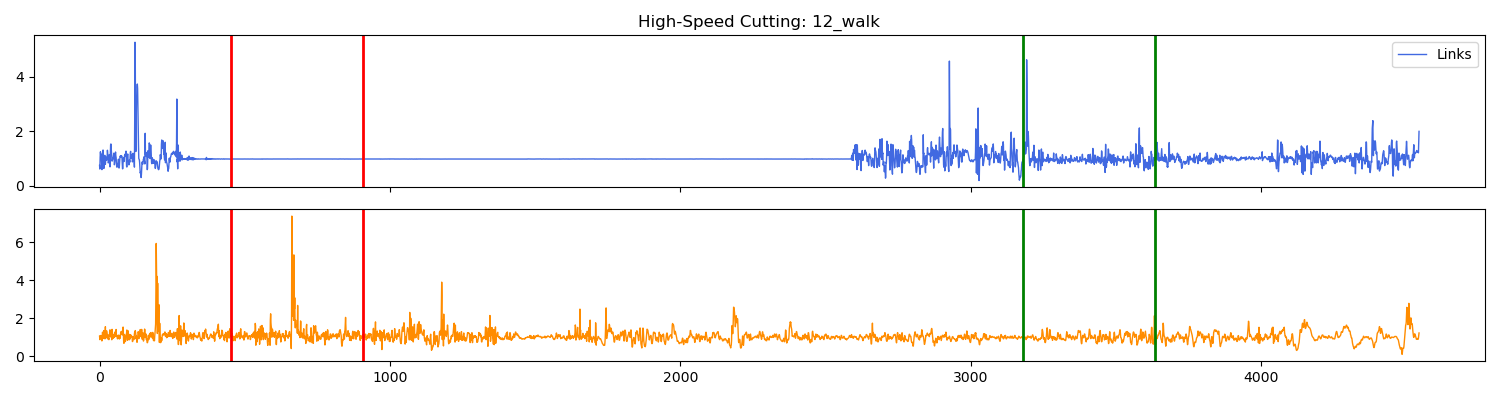

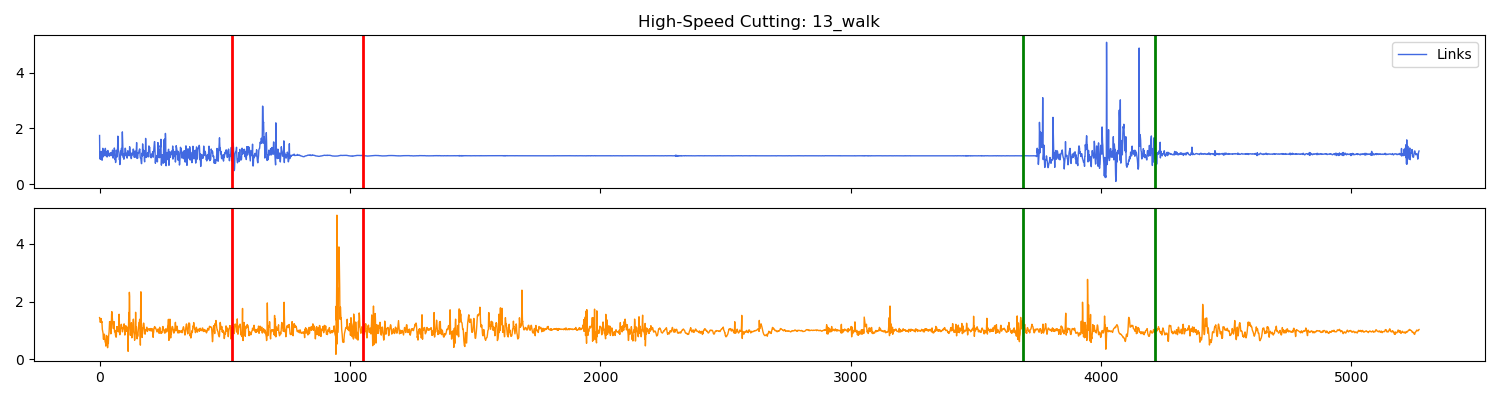

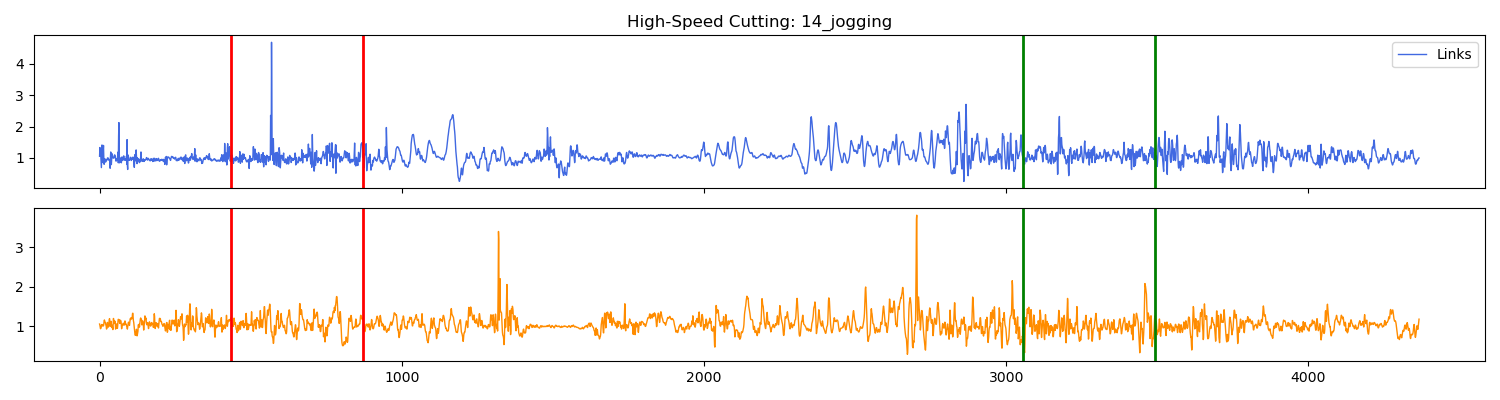

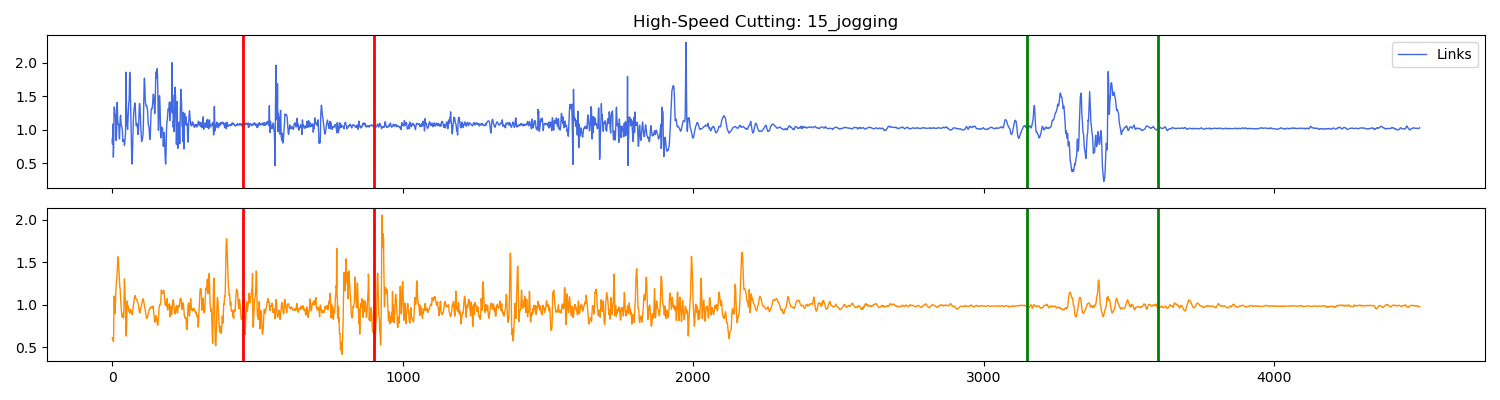

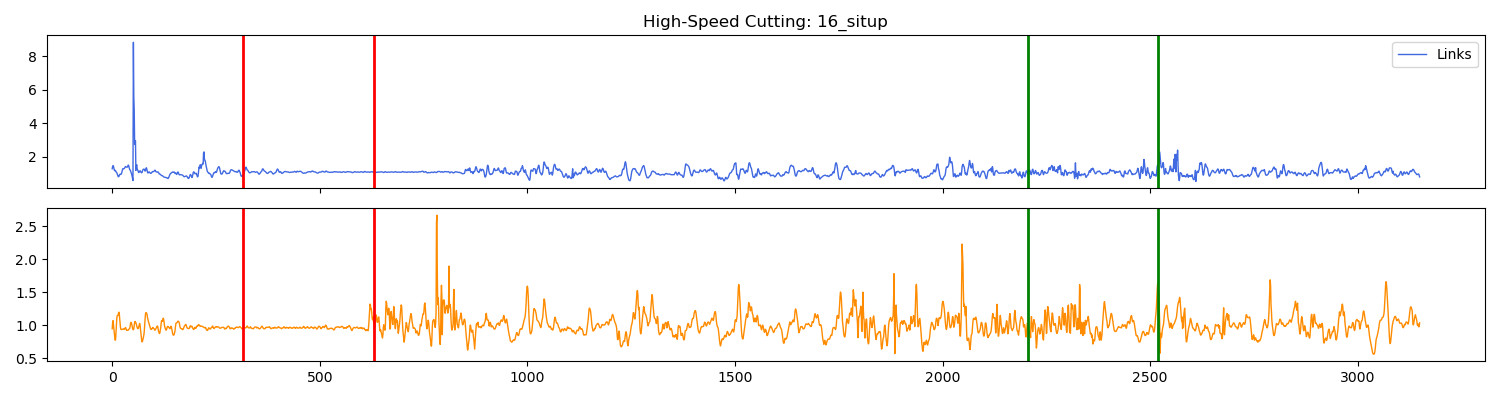

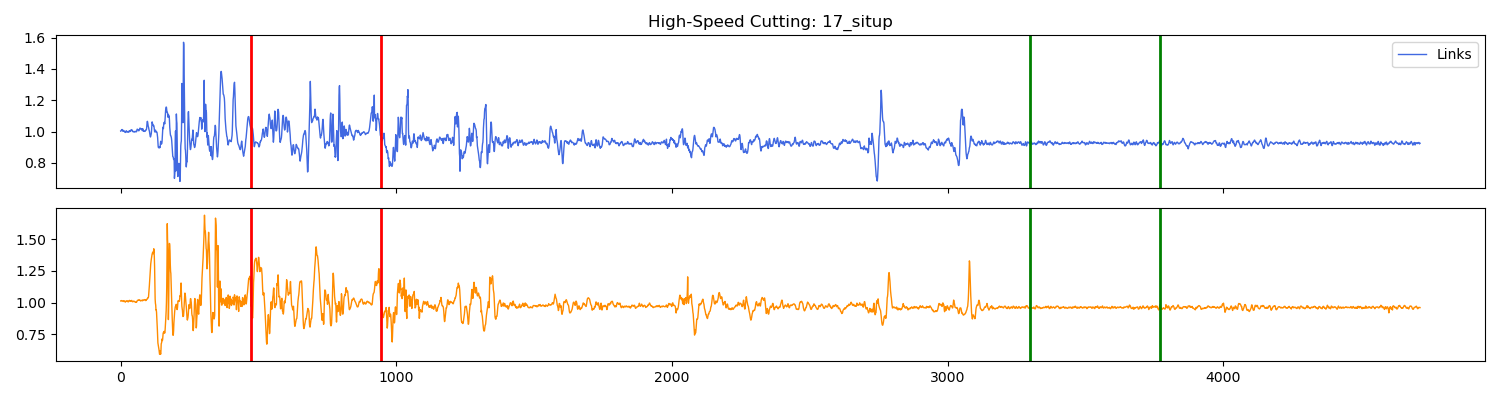

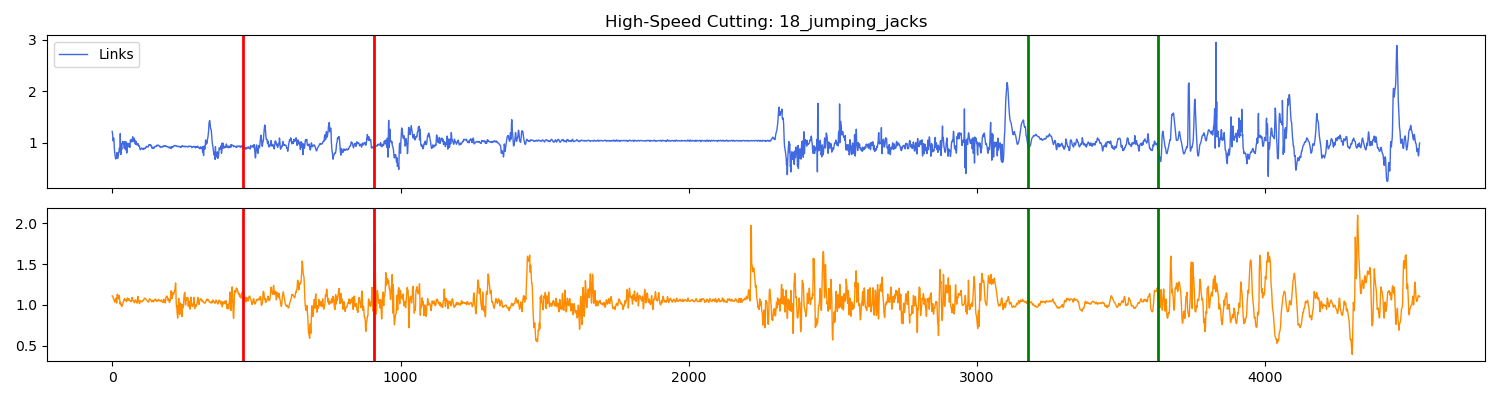

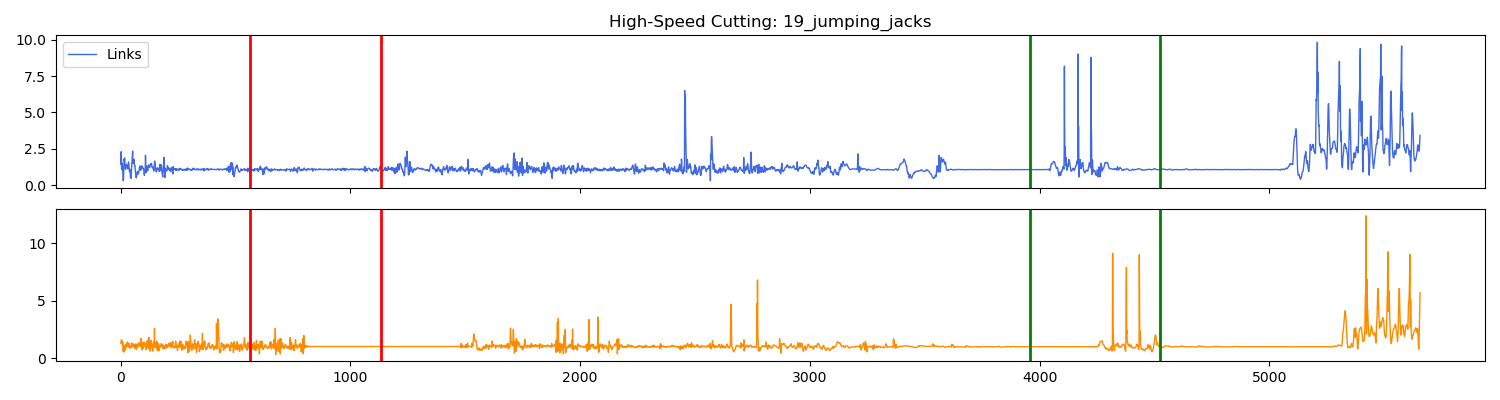

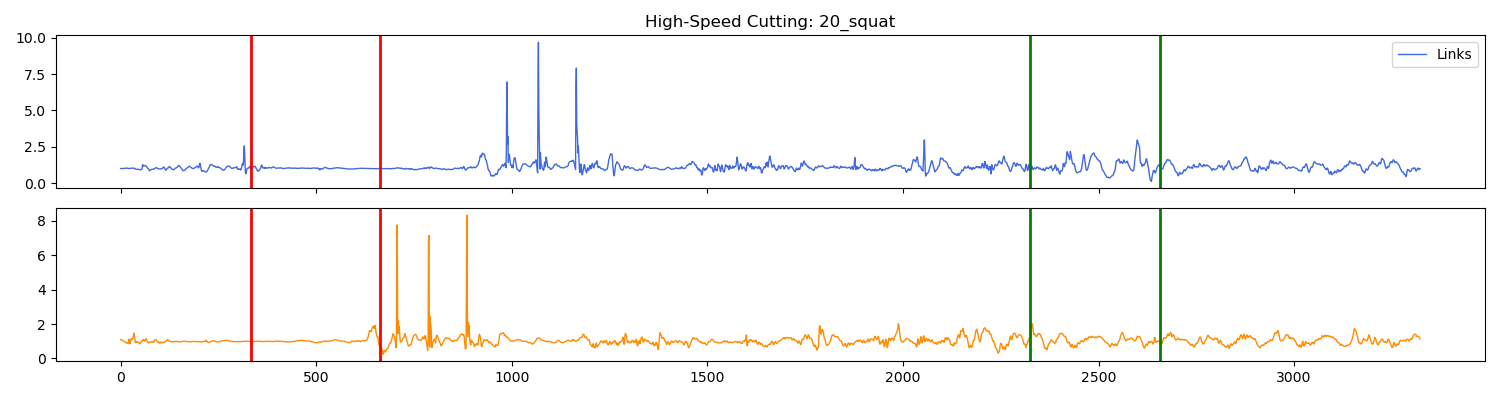

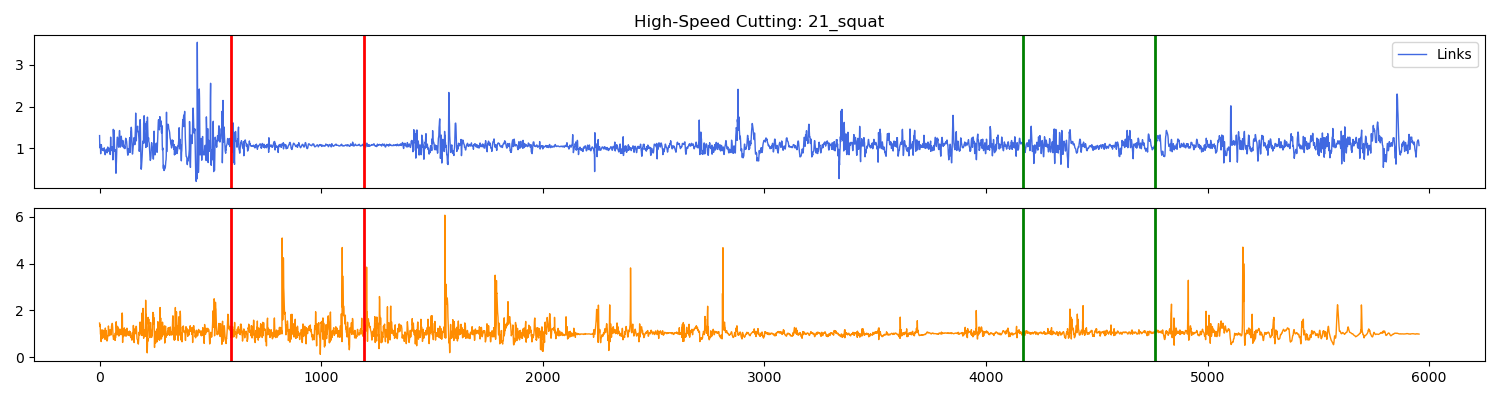

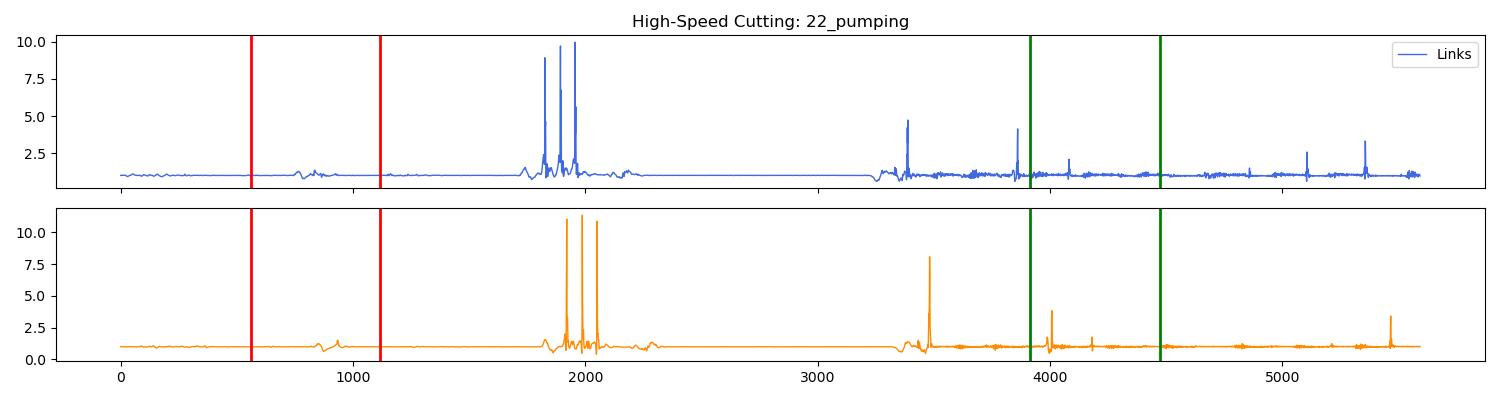

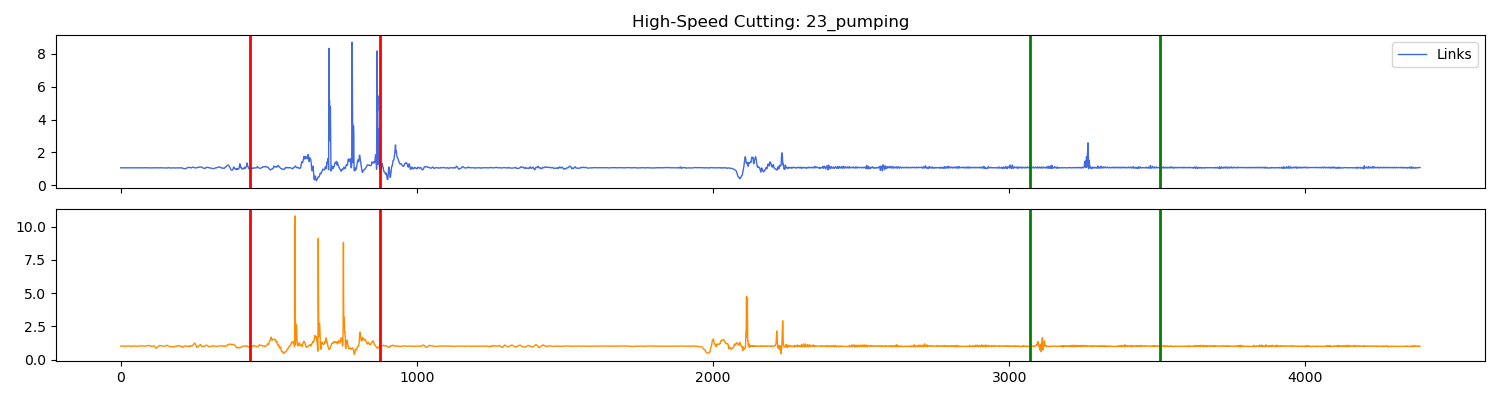

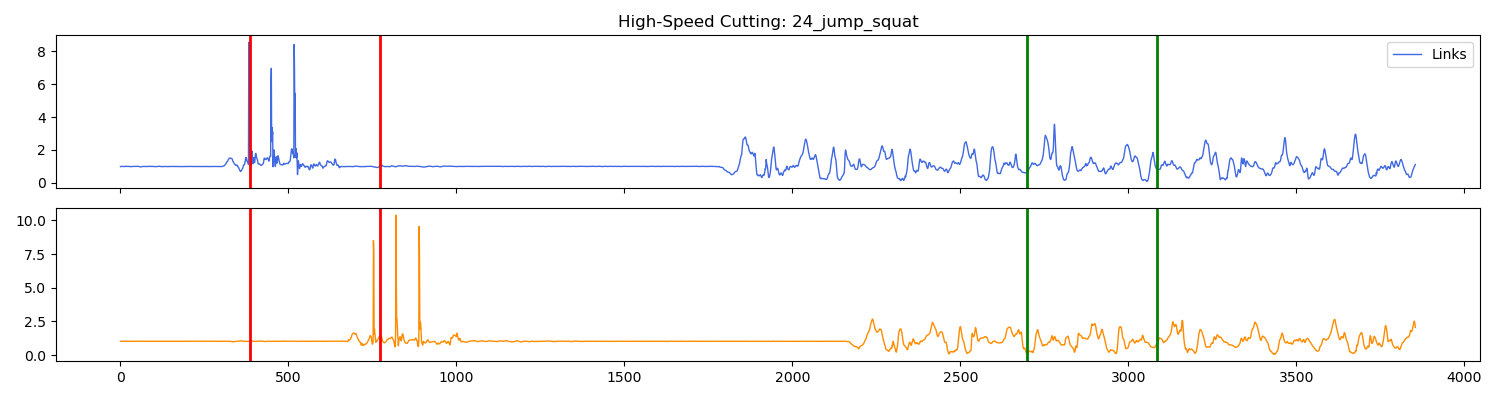

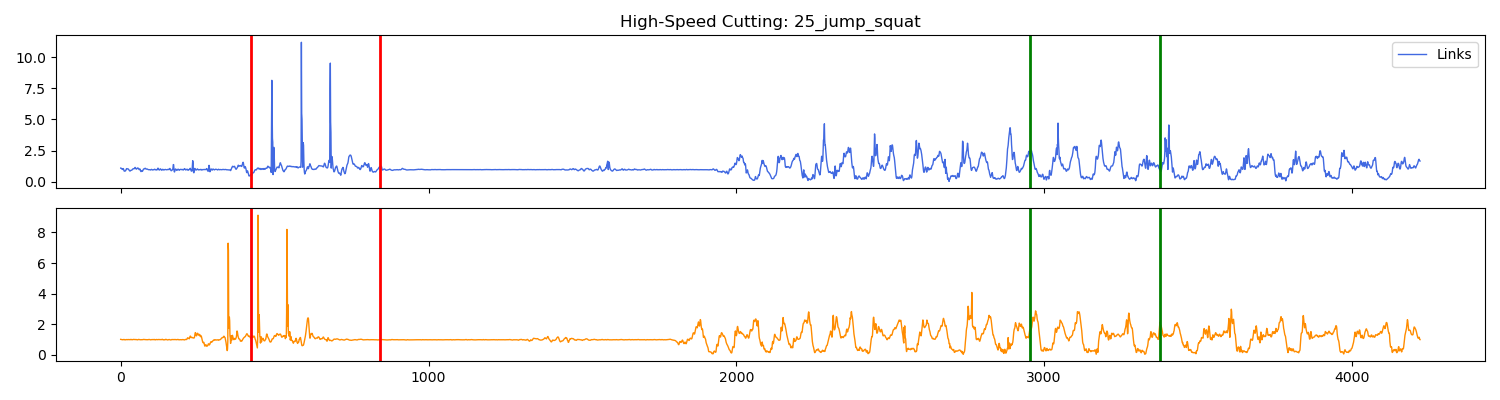

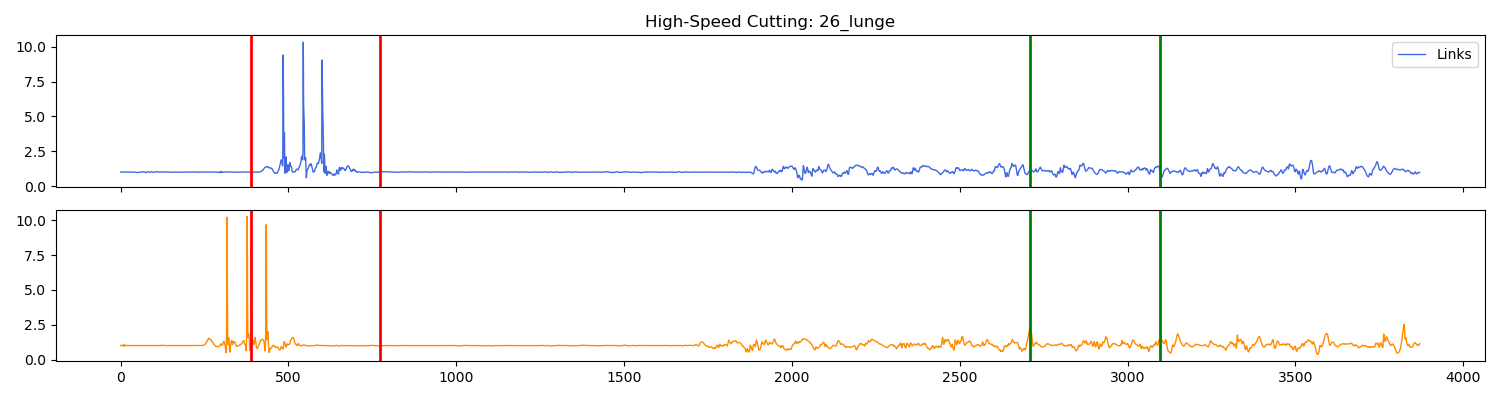

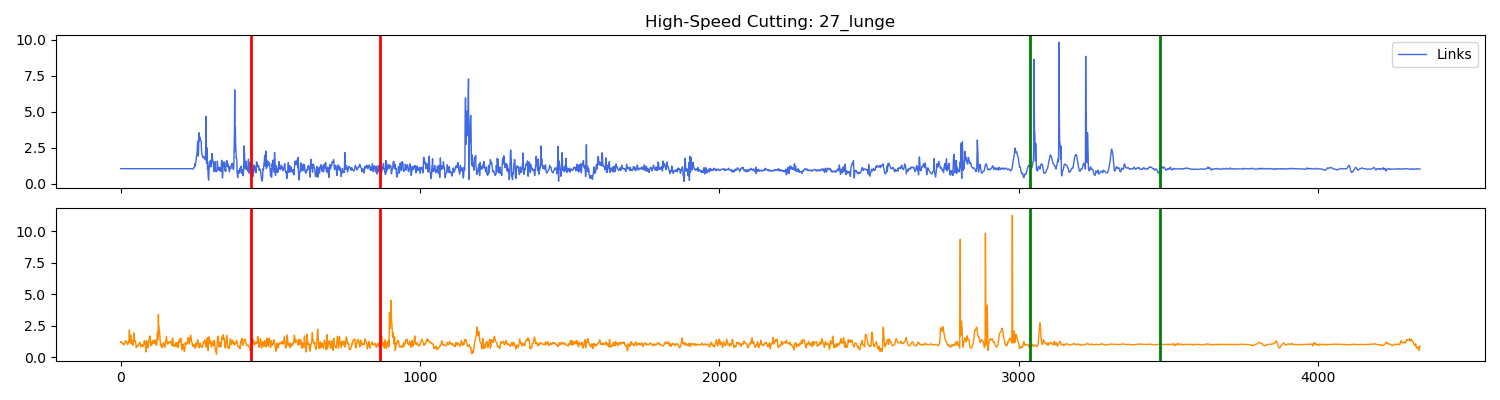

In [28]:
sessions = list(range(12, 28))  # 12..27
cutters = [
    FourLineCutter(dfL, dfR, f"{sid}_{default_session_to_activity()[sid]}")
    for sid, (dfL, dfR) in zip(sessions, dfs_synced)
]

In [29]:
tensors = [c.get_data() for c in cutters]

### Save the files

In [30]:
import os

os.makedirs(ACTIVE_SECTIONS_DATA_ROOT, exist_ok=True)

for (t1, t2), sid in zip(tensors, range(12, 28)):
    file1 = os.path.join(ACTIVE_SECTIONS_DATA_ROOT, f"{sid}part1.csv")
    file2 = os.path.join(ACTIVE_SECTIONS_DATA_ROOT, f"{sid}part2.csv")

    if not os.path.exists(file1):
        t1.to_csv(file1, index=False)
        t2.to_csv(file2, index=False)
        print(f"Saved session {sid}")
    else:
        print(f"Session {sid} already exists, skipped")

Saved session 12
Saved session 13
Saved session 14
Saved session 15
Saved session 16
Saved session 17
Saved session 18
Saved session 19
Saved session 20
Saved session 21
Saved session 22
Saved session 23
Saved session 24
Saved session 25
Saved session 26
Saved session 27


In [31]:
print("Sessions:", sessions)


Sessions: [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
